In [8]:
import cv2

# Load the image in grayscale
img = cv2.imread('cameraman.png', cv2.IMREAD_GRAYSCALE)


In [9]:
# Set the threshold values
threshold_values = [0, 50, 100, 150, 200]

# Apply thresholding with different threshold values
for threshold_value in threshold_values:
    ret, thresh = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY)
    cv2.imshow(f'Thresholded Image ({threshold_value})', thresh)



In [10]:
# Display the original image
cv2.imshow('Original Image', img)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [11]:
# Task#2: Histogram Processing

# Step#1: Load necessary libraries
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from skimage import data, img_as_float
from skimage import exposure

# Step#2: Load moon image
img = data.moon()


In [12]:
# Step#3: Rescale intensity values to include all the intensities that fall within the 2nd and 98th percentiles
# Contrast stretching
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))


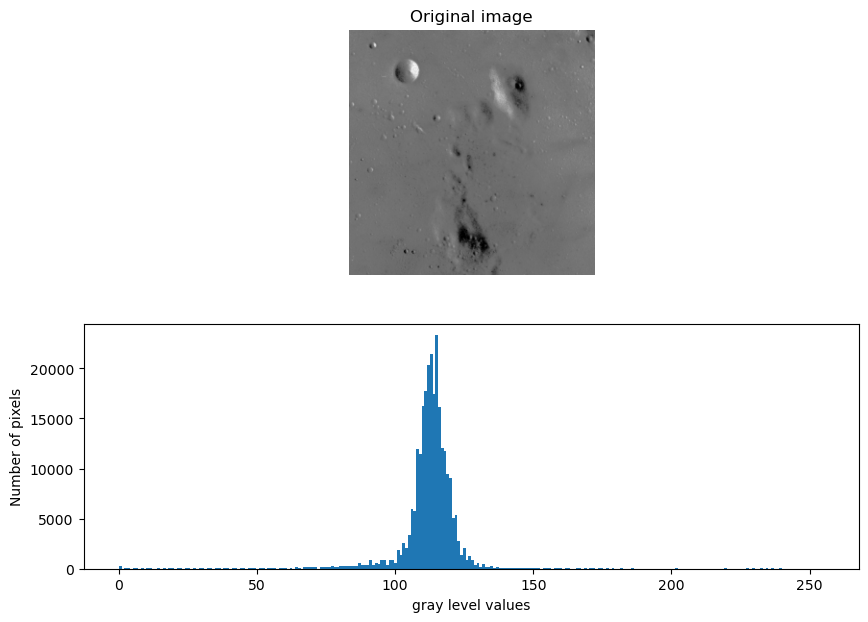

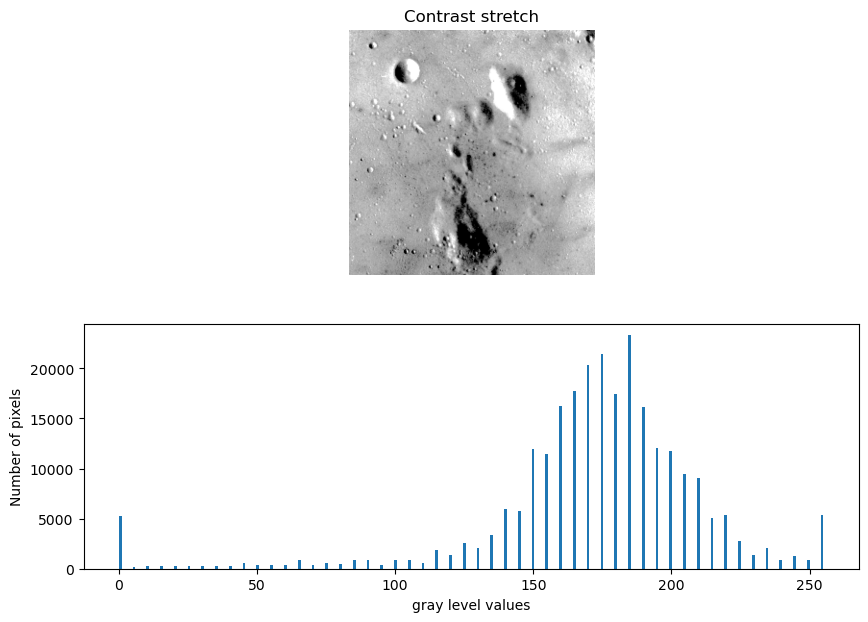

In [13]:
# Step#4: Display the image with its histogram of (step#2)  and (step#3)

fig = plt.figure(figsize=(10, 7)) 
fig.add_subplot(2, 1, 1) 
plt.imshow(img, cmap = 'gray') 
plt.axis('off') 
plt.title('Original image') 
fig.add_subplot(2, 1, 2) 
plt.hist(img.flat, bins = 256, range=(0, 255)) 
plt.xlabel('gray level values') 
plt.ylabel('Number of pixels') 
plt.show() 
fig = plt.figure(figsize=(10, 7)) 
fig.add_subplot(2, 1, 1) 
plt.imshow(img_rescale, cmap = 'gray') 
plt.axis('off') 
plt.title('Contrast stretch')
fig.add_subplot(2, 1, 2) 
plt.hist(img_rescale.flat, bins = 256, range=(0, 255)) 
plt.xlabel('gray level values') 
plt.ylabel('Number of pixels') 
plt.show() 

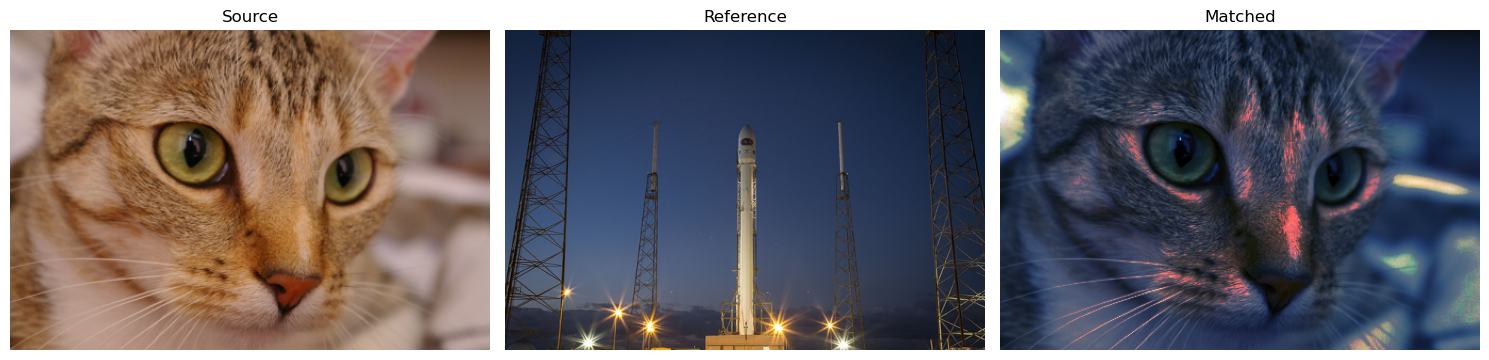

In [14]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from skimage import data, exposure
from skimage.exposure import match_histograms
import os

# Create the outputs folder if it doesn't exist to prevent the error
if not os.path.exists('outputs'):
    os.makedirs('outputs')

# Load the image (ensure 'cameraman.png' is in your lab folder)
img_cameraman = cv2.imread('cameraman.png', cv2.IMREAD_GRAYSCALE)

# Check if image loaded correctly to avoid empty image error
if img_cameraman is None:
    print("Error: Could not find cameraman.png. Please check the file path.")
else:
    threshold_values = [0, 50, 100, 150, 200]
    for val in threshold_values:
        ret, thresh = cv2.threshold(img_cameraman, val, 255, cv2.THRESH_BINARY)
        # This will now work because the folder exists and the image is loaded
        cv2.imwrite(f'outputs/threshold_{val}.png', thresh)

# Task #1 & #2: Moon Image
img_moon = data.moon()

p3, p80 = np.percentile(img_moon, (3, 80))
img_rescale = exposure.rescale_intensity(img_moon, in_range=(p3, p80))

plt.figure(figsize=(10, 8))
plt.subplot(2, 1, 1)
plt.imshow(img_rescale, cmap='gray')
plt.axis('off')
plt.subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins=256, range=(0, 255), color='gray')
plt.savefig('outputs/task1_moon_rescale.png')
plt.close()

img_eq = exposure.equalize_hist(img_moon)

plt.figure(figsize=(10, 8))
plt.subplot(2, 1, 1)
plt.imshow(img_eq, cmap='gray')
plt.axis('off')
plt.subplot(2, 1, 2)
plt.hist(img_eq.flat, bins=256, color='blue')
plt.savefig('outputs/task2_moon_equalize.png')
plt.close()

# Task #3: Histogram Matching
source = data.chelsea()
reference = data.rocket()
matched = match_histograms(source, reference, channel_axis=-1)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
ax1.imshow(source)
ax1.axis('off')
ax1.set_title('Source')

ax2.imshow(reference)
ax2.axis('off')
ax2.set_title('Reference')

ax3.imshow(matched)
ax3.axis('off')
ax3.set_title('Matched')

plt.tight_layout()
plt.savefig('outputs/task3_histogram_matching.png')
plt.show()